In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STATION_COMPARE_PATH = os.path.join(
    OUTPUT_DIR,
    "layer1_weekday_weekend_return_station_comparison.csv"
)

SERVICE_COUNTS_250_PATH = os.path.join(
    OUTPUT_DIR,
    "top20_end_station_osm_service_counts_250m.csv"
)

station_compare = pd.read_csv(STATION_COMPARE_PATH)
service_counts_250 = pd.read_csv(SERVICE_COUNTS_250_PATH)

station_compare["end_station_name"] = station_compare["end_station_name"].astype(str).str.strip()
service_counts_250["end_station_name"] = service_counts_250["end_station_name"].astype(str).str.strip()


def identify_service_columns(service_df):
    """
    Identify numeric OSM service category columns.
    """
    non_service_cols = {
        "end_station_name",
        "end_trip_count",
        "station_end_trip_count",
        "end_lat",
        "end_lng",
        "station_lat",
        "station_lng",
        "search_radius_m",
        "matched_address"
    }
    
    service_cols = []
    
    for col in service_df.columns:
        if col in non_service_cols:
            continue
        if col.startswith("total_services"):
            continue
        if pd.api.types.is_numeric_dtype(service_df[col]):
            service_cols.append(col)
    
    return service_cols


def prepare_profile_data(station_compare, service_counts):
    """
    Merge station return comparison with OSM service counts.
    """
    df = station_compare.merge(
        service_counts,
        on="end_station_name",
        how="inner",
        suffixes=("", "_service")
    )
    
    service_cols = identify_service_columns(service_counts)
    
    return df, service_cols


def weighted_service_profile(df, service_cols, weight_col, normalize_station_profile=True):
    """
    Compute weighted service profile.
    
    If normalize_station_profile=True:
    each station's service vector is converted into proportions first.
    
    Then station profiles are averaged using return counts as weights.
    """
    service_matrix = df[service_cols].fillna(0).astype(float).copy()
    
    if normalize_station_profile:
        row_sum = service_matrix.sum(axis=1)
        service_matrix = service_matrix.div(row_sum.replace(0, np.nan), axis=0).fillna(0)
    
    weights = df[weight_col].fillna(0).astype(float).values
    
    if weights.sum() == 0:
        return pd.Series(np.zeros(len(service_cols)), index=service_cols)
    
    weights = weights / weights.sum()
    
    profile = (service_matrix.values * weights[:, None]).sum(axis=0)
    
    return pd.Series(profile, index=service_cols)


profile_df_250, service_cols_250 = prepare_profile_data(
    station_compare,
    service_counts_250
)

print("Merged profile dataset:", profile_df_250.shape)
print("Service columns:", service_cols_250)

display(profile_df_250.head())

Merged profile dataset: (20, 25)
Service columns: ['education', 'food_drink', 'health', 'office', 'other_amenity', 'recreation', 'retail', 'tourism', 'transit']


,end_station_name,return_count_weekday,return_count_weekend,return_share_weekday,return_share_weekend,end_lat,end_lng,total_return_count,weekend_minus_weekday_share,weekday_minus_weekend_share,...,education,food_drink,health,office,other_amenity,recreation,retail,tourism,transit,total_services_250m
0,Canal St & Adams St,19724.0,1747.0,0.006358,0.001447,41.879255,-87.639904,21471.0,-0.004911,0.004911,...,4.0,41.0,2.0,11.0,133.0,104.0,14.0,3.0,82.0,394.0
1,Canal St & Madison St,26693.0,2608.0,0.008604,0.002160,41.882409,-87.639767,29301.0,-0.006444,0.006444,...,1.0,48.0,1.0,17.0,146.0,135.0,27.0,2.0,57.0,434.0
2,Clark St & Elm St,20810.0,8555.0,0.006708,0.007087,41.903017,-87.631523,29365.0,0.000379,-0.000379,...,2.0,37.0,2.0,1.0,31.0,14.0,20.0,3.0,48.0,158.0
3,Clinton St & Jackson Blvd,21413.0,2302.0,0.006902,0.001907,41.878317,-87.640981,23715.0,-0.004995,0.004995,...,3.0,32.0,2.0,8.0,138.0,67.0,14.0,3.0,85.0,352.0
4,Clinton St & Madison St,25104.0,4057.0,0.008092,0.003361,41.882750,-87.641190,29161.0,-0.004731,0.004731,...,1.0,60.0,1.0,10.0,132.0,87.0,29.0,5.0,64.0,389.0


In [2]:
# =========================
# Baseline: station count ranking only
# =========================

baseline_weekday_top20 = (
    station_compare
    .sort_values("return_count_weekday", ascending=False)
    .head(20)
    .copy()
)

baseline_weekend_top20 = (
    station_compare
    .sort_values("return_count_weekend", ascending=False)
    .head(20)
    .copy()
)

baseline_weekday_top20.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_top20_weekday_return_stations.csv"),
    index=False
)

baseline_weekend_top20.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_top20_weekend_return_stations.csv"),
    index=False
)

print("Baseline top 20 weekday return stations")
display(baseline_weekday_top20[[
    "end_station_name",
    "return_count_weekday",
    "return_share_weekday",
    "end_lat",
    "end_lng"
]])

print("Baseline top 20 weekend return stations")
display(baseline_weekend_top20[[
    "end_station_name",
    "return_count_weekend",
    "return_share_weekend",
    "end_lat",
    "end_lng"
]])

Baseline top 20 weekday return stations


,end_station_name,return_count_weekday,return_share_weekday,end_lat,end_lng
505,Kingsbury St & Kinzie St,31094.0,0.010023,41.889173,-87.638500
216,Clinton St & Washington Blvd,29100.0,0.009380,41.883379,-87.641170
132,Canal St & Madison St,26693.0,0.008604,41.882409,-87.639767
212,Clinton St & Madison St,25104.0,0.008092,41.882750,-87.641190
210,Clinton St & Jackson Blvd,21413.0,0.006902,41.878317,-87.640981
666,Michigan Ave & Oak St,21157.0,0.006820,41.900960,-87.623777
183,Clark St & Elm St,20810.0,0.006708,41.903017,-87.631523
297,DuSable Lake Shore Dr & Monroe St,20698.0,0.006672,41.880958,-87.616743
298,DuSable Lake Shore Dr & North Blvd,19730.0,0.006360,41.911722,-87.626804
129,Canal St & Adams St,19724.0,0.006358,41.879255,-87.639904


Baseline top 20 weekend return stations


,end_station_name,return_count_weekend,return_share_weekend,end_lat,end_lng
297,DuSable Lake Shore Dr & Monroe St,17218.0,0.014263,41.880958,-87.616743
715,Navy Pier,15617.0,0.012937,41.892278,-87.612043
298,DuSable Lake Shore Dr & North Blvd,14940.0,0.012376,41.911722,-87.626804
666,Michigan Ave & Oak St,13471.0,0.011159,41.900960,-87.623777
1014,Theater on the Lake,12444.0,0.010308,41.926277,-87.630834
1010,Streeter Dr & Grand Ave,12071.0,0.009999,41.892278,-87.612043
673,Millennium Park,10356.0,0.008579,41.881032,-87.624084
1073,Wells St & Concord Ln,9219.0,0.007637,41.912133,-87.634656
505,Kingsbury St & Kinzie St,8919.0,0.007388,41.889173,-87.638500
191,Clark St & Lincoln Ave,8838.0,0.007321,41.915689,-87.634600


In [3]:
# =========================
# Profiling model: weighted service profile
# =========================

weekday_profile_250 = weighted_service_profile(
    profile_df_250,
    service_cols_250,
    weight_col="return_count_weekday",
    normalize_station_profile=True
)

weekend_profile_250 = weighted_service_profile(
    profile_df_250,
    service_cols_250,
    weight_col="return_count_weekend",
    normalize_station_profile=True
)

service_profile_comparison_250 = pd.DataFrame({
    "service_category": service_cols_250,
    "weekday_profile": weekday_profile_250.values,
    "weekend_profile": weekend_profile_250.values
})

service_profile_comparison_250["weekend_minus_weekday"] = (
    service_profile_comparison_250["weekend_profile"] -
    service_profile_comparison_250["weekday_profile"]
)

service_profile_comparison_250 = service_profile_comparison_250.sort_values(
    "weekend_minus_weekday",
    ascending=False
)

output_csv = os.path.join(
    OUTPUT_DIR,
    "validation1_weekday_weekend_service_profile_comparison_250m.csv"
)

service_profile_comparison_250.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(service_profile_comparison_250)

Saved: outputs\validation1_weekday_weekend_service_profile_comparison_250m.csv


,service_category,weekday_profile,weekend_profile,weekend_minus_weekday
5,recreation,0.232344,0.259521,0.027177
7,tourism,0.022918,0.030923,0.008005
0,education,0.011482,0.012285,0.000803
2,health,0.008086,0.008396,0.000310
6,retail,0.080907,0.080034,-0.000873
3,office,0.019963,0.013582,-0.006381
4,other_amenity,0.334946,0.326778,-0.008168
1,food_drink,0.131709,0.122304,-0.009405
8,transit,0.157645,0.146177,-0.011468


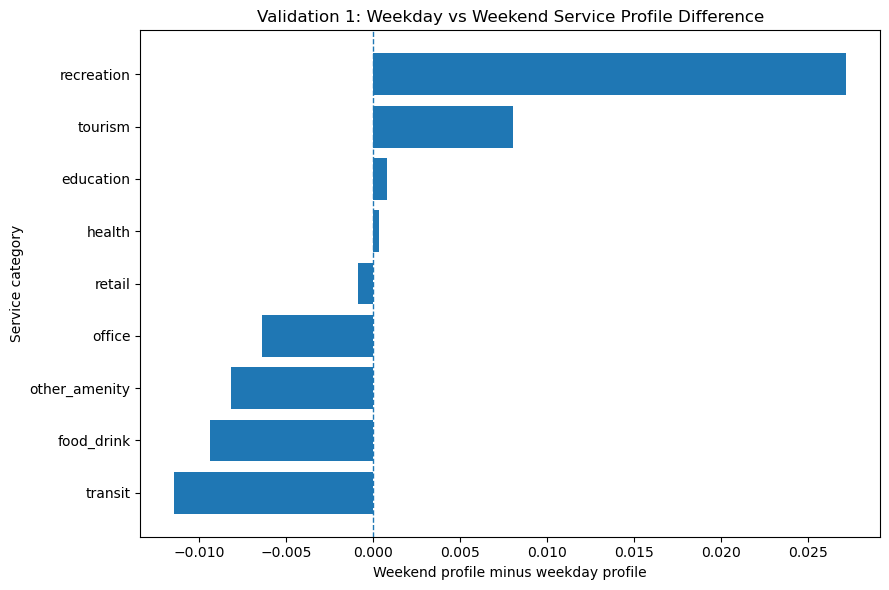

Saved: outputs\validation1_weekday_weekend_service_profile_difference.png


In [4]:
plot_df = service_profile_comparison_250.sort_values("weekend_minus_weekday")

plt.figure(figsize=(9, 6))
plt.barh(
    plot_df["service_category"],
    plot_df["weekend_minus_weekday"]
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Weekend profile minus weekday profile")
plt.ylabel("Service category")
plt.title("Validation 1: Weekday vs Weekend Service Profile Difference")
plt.tight_layout()

output_fig = os.path.join(
    OUTPUT_DIR,
    "validation1_weekday_weekend_service_profile_difference.png"
)

plt.savefig(output_fig, dpi=300)
plt.show()

print("Saved:", output_fig)

In [5]:
# =========================
# Validation 2: Random shuffle test
# =========================

df = profile_df_250.copy()
service_cols = service_cols_250.copy()

# Station service profiles
service_matrix = df[service_cols].fillna(0).astype(float)
row_sum = service_matrix.sum(axis=1)
station_service_profile = service_matrix.div(row_sum.replace(0, np.nan), axis=0).fillna(0)

def compute_profile_from_weights(weights):
    weights = np.asarray(weights, dtype=float)
    
    if weights.sum() == 0:
        return np.zeros(len(service_cols))
    
    weights = weights / weights.sum()
    return (station_service_profile.values * weights[:, None]).sum(axis=0)

# Observed difference
weekday_weights_obs = df["return_count_weekday"].fillna(0).astype(int).values
weekend_weights_obs = df["return_count_weekend"].fillna(0).astype(int).values

weekday_profile_obs = compute_profile_from_weights(weekday_weights_obs)
weekend_profile_obs = compute_profile_from_weights(weekend_weights_obs)

# L1 distance between profiles
observed_diff = np.abs(weekend_profile_obs - weekday_profile_obs).sum()

print("Observed weekday-weekend service profile difference:", observed_diff)

# Permutation test
rng = np.random.default_rng(42)
n_perm = 1000

station_total_returns = weekday_weights_obs + weekend_weights_obs

total_weekend_returns = weekend_weights_obs.sum()
total_all_returns = station_total_returns.sum()

p_weekend = total_weekend_returns / total_all_returns

perm_diffs = []

for i in range(n_perm):
    # Approximate random shuffle:
    # each station's total returns are randomly split into weekday/weekend
    shuffled_weekend = rng.binomial(station_total_returns, p_weekend)
    shuffled_weekday = station_total_returns - shuffled_weekend
    
    shuffled_weekday_profile = compute_profile_from_weights(shuffled_weekday)
    shuffled_weekend_profile = compute_profile_from_weights(shuffled_weekend)
    
    shuffled_diff = np.abs(
        shuffled_weekend_profile - shuffled_weekday_profile
    ).sum()
    
    perm_diffs.append(shuffled_diff)

perm_diffs = np.array(perm_diffs)

p_value = (np.sum(perm_diffs >= observed_diff) + 1) / (n_perm + 1)

shuffle_result = pd.DataFrame({
    "observed_profile_difference": [observed_diff],
    "mean_shuffled_difference": [perm_diffs.mean()],
    "std_shuffled_difference": [perm_diffs.std()],
    "p_value": [p_value],
    "n_permutations": [n_perm],
    "interpretation": [
        "Small p-value means observed weekday/weekend service-profile difference is larger than most random label shuffles."
    ]
})

output_csv = os.path.join(
    OUTPUT_DIR,
    "validation2_weekday_weekend_shuffle_test.csv"
)

shuffle_result.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(shuffle_result)

Observed weekday-weekend service profile difference: 0.07258939513254238
Saved: outputs\validation2_weekday_weekend_shuffle_test.csv


,observed_profile_difference,mean_shuffled_difference,std_shuffled_difference,p_value,n_permutations,interpretation
0,0.072589,0.001325,0.000605,0.000999,1000,Small p-value means observed weekday/weekend s...


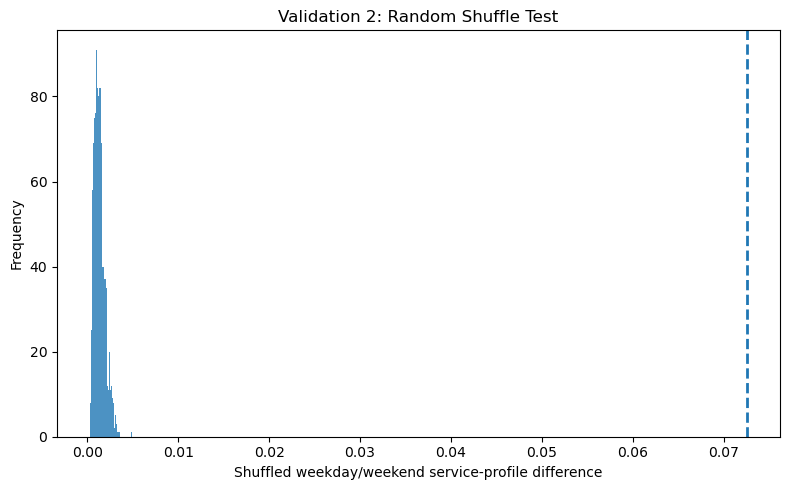

Saved: outputs\validation2_shuffle_test_weekday_weekend_service_profile.png


In [6]:
plt.figure(figsize=(8, 5))
plt.hist(perm_diffs, bins=40, alpha=0.8)
plt.axvline(observed_diff, linestyle="--", linewidth=2)

plt.xlabel("Shuffled weekday/weekend service-profile difference")
plt.ylabel("Frequency")
plt.title("Validation 2: Random Shuffle Test")
plt.tight_layout()

output_fig = os.path.join(
    OUTPUT_DIR,
    "validation2_shuffle_test_weekday_weekend_service_profile.png"
)

plt.savefig(output_fig, dpi=300)
plt.show()

print("Saved:", output_fig)

In [7]:
# If needed:
# %pip install osmnx geopandas shapely

import time
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point

MAX_RADIUS_M = 500

OSM_DETAIL_500_PATH = os.path.join(
    OUTPUT_DIR,
    "validation3_top20_osm_services_max500m_detail.csv"
)

# Use top 20 high-volume return stations from the station comparison table
top20_for_radius = (
    station_compare
    .sort_values("total_return_count", ascending=False)
    .head(20)
    .copy()
)

top20_for_radius = top20_for_radius.dropna(subset=["end_lat", "end_lng"]).copy()

top20_for_radius = top20_for_radius[[
    "end_station_name",
    "total_return_count",
    "end_lat",
    "end_lng"
]].rename(columns={
    "total_return_count": "end_trip_count"
})

top20_for_radius["end_station_name"] = top20_for_radius["end_station_name"].astype(str).str.strip()

display(top20_for_radius)


OSM_TAGS = {
    "amenity": True,
    "shop": True,
    "tourism": True,
    "office": True,
    "leisure": True,
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"],
    "healthcare": True
}


def get_tag(row, col):
    if col not in row.index:
        return ""
    value = row[col]
    if pd.isna(value):
        return ""
    return str(value).lower()


def classify_osm_service(row):
    amenity = get_tag(row, "amenity")
    shop = get_tag(row, "shop")
    tourism = get_tag(row, "tourism")
    office = get_tag(row, "office")
    leisure = get_tag(row, "leisure")
    public_transport = get_tag(row, "public_transport")
    railway = get_tag(row, "railway")
    healthcare = get_tag(row, "healthcare")

    food_drink = {
        "restaurant", "cafe", "bar", "pub", "fast_food",
        "food_court", "ice_cream", "biergarten"
    }

    transit = {
        "bus_station", "ferry_terminal", "taxi"
    }

    education = {
        "school", "college", "university", "library",
        "kindergarten"
    }

    health = {
        "hospital", "clinic", "doctors", "dentist", "pharmacy"
    }

    if amenity in food_drink:
        return "food_drink"

    if amenity in transit or public_transport != "" or railway in ["station", "subway_entrance", "tram_stop"]:
        return "transit"

    if shop != "":
        return "retail"

    if tourism != "":
        return "tourism"

    if office != "":
        return "office"

    if amenity in health or healthcare != "":
        return "health"

    if leisure != "":
        return "recreation"

    if amenity in education:
        return "education"

    if amenity != "":
        return "other_amenity"

    return "other_service"


if os.path.exists(OSM_DETAIL_500_PATH):
    print("Cached OSM detail file already exists. Reading:")
    print(OSM_DETAIL_500_PATH)
    osm_detail_500 = pd.read_csv(OSM_DETAIL_500_PATH)

else:
    all_service_rows = []

    for _, station in top20_for_radius.iterrows():
        station_name = station["end_station_name"]
        lat = station["end_lat"]
        lng = station["end_lng"]

        print(f"Querying OSM services within {MAX_RADIUS_M}m around: {station_name}")

        try:
            gdf = ox.features_from_point(
                center_point=(lat, lng),
                tags=OSM_TAGS,
                dist=MAX_RADIUS_M
            )

            if gdf.empty:
                print("  No services found.")
                continue

            gdf = gdf.reset_index()
            gdf = gdf[gdf.geometry.notna()].copy()
            gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

            # Classify service category
            gdf["service_category"] = gdf.apply(classify_osm_service, axis=1)

            # Project to meters for distance calculation
            gdf_proj = gdf.to_crs("EPSG:26916")
            service_centroids_proj = gdf_proj.geometry.centroid

            station_point_wgs = gpd.GeoSeries(
                [Point(lng, lat)],
                crs="EPSG:4326"
            )

            station_point_proj = station_point_wgs.to_crs("EPSG:26916").iloc[0]

            distances_m = service_centroids_proj.distance(station_point_proj)

            # Convert centroids back to WGS84
            service_centroids_wgs = gpd.GeoSeries(
                service_centroids_proj,
                crs="EPSG:26916"
            ).to_crs("EPSG:4326")

            gdf["service_lng"] = service_centroids_wgs.x.values
            gdf["service_lat"] = service_centroids_wgs.y.values
            gdf["distance_m"] = distances_m.values

            gdf["end_station_name"] = station_name
            gdf["station_end_trip_count"] = station["end_trip_count"]
            gdf["station_lat"] = lat
            gdf["station_lng"] = lng

            useful_cols = [
                "end_station_name",
                "station_end_trip_count",
                "station_lat",
                "station_lng",
                "service_category",
                "service_lat",
                "service_lng",
                "distance_m",
                "name",
                "amenity",
                "shop",
                "tourism",
                "office",
                "leisure",
                "public_transport",
                "railway",
                "healthcare"
            ]

            existing_cols = [c for c in useful_cols if c in gdf.columns]

            all_service_rows.append(gdf[existing_cols].copy())

            print(f"  Found {len(gdf)} OSM features.")
            time.sleep(1)

        except Exception as e:
            print(f"  Error for {station_name}: {e}")

    if len(all_service_rows) > 0:
        osm_detail_500 = pd.concat(all_service_rows, ignore_index=True)
    else:
        osm_detail_500 = pd.DataFrame()

    osm_detail_500.to_csv(OSM_DETAIL_500_PATH, index=False)

    print("Saved:")
    print(OSM_DETAIL_500_PATH)

print("OSM detail rows:", len(osm_detail_500))
display(osm_detail_500.head())

,end_station_name,end_trip_count,end_lat,end_lng
505,Kingsbury St & Kinzie St,40013.0,41.889173,-87.638500
297,DuSable Lake Shore Dr & Monroe St,37916.0,41.880958,-87.616743
715,Navy Pier,34777.0,41.892278,-87.612043
298,DuSable Lake Shore Dr & North Blvd,34670.0,41.911722,-87.626804
666,Michigan Ave & Oak St,34628.0,41.900960,-87.623777
216,Clinton St & Washington Blvd,30589.0,41.883379,-87.641170
1010,Streeter Dr & Grand Ave,29925.0,41.892278,-87.612043
183,Clark St & Elm St,29365.0,41.903017,-87.631523
132,Canal St & Madison St,29301.0,41.882409,-87.639767
212,Clinton St & Madison St,29161.0,41.882750,-87.641190


Querying OSM services within 500m around: Kingsbury St & Kinzie St
  Found 879 OSM features.
Querying OSM services within 500m around: DuSable Lake Shore Dr & Monroe St
  Found 464 OSM features.
Querying OSM services within 500m around: Navy Pier
  Found 497 OSM features.
Querying OSM services within 500m around: DuSable Lake Shore Dr & North Blvd
  Found 276 OSM features.
Querying OSM services within 500m around: Michigan Ave & Oak St
  Found 690 OSM features.
Querying OSM services within 500m around: Clinton St & Washington Blvd
  Found 1241 OSM features.
Querying OSM services within 500m around: Streeter Dr & Grand Ave
  Found 497 OSM features.
Querying OSM services within 500m around: Clark St & Elm St
  Found 501 OSM features.
Querying OSM services within 500m around: Canal St & Madison St
  Found 1534 OSM features.
Querying OSM services within 500m around: Clinton St & Madison St
  Found 1328 OSM features.
Querying OSM services within 500m around: Theater on the Lake
  Found 256 

,end_station_name,station_end_trip_count,station_lat,station_lng,service_category,service_lat,service_lng,distance_m,name,amenity,shop,tourism,office,leisure,public_transport,railway,healthcare
0,Kingsbury St & Kinzie St,40013.0,41.889173,-87.6385,transit,41.885726,-87.641865,473.767037,Clinton,NaN,NaN,NaN,NaN,NaN,station,station,NaN
1,Kingsbury St & Kinzie St,40013.0,41.889173,-87.6385,transit,41.885703,-87.641233,447.004009,Clinton,NaN,NaN,NaN,NaN,NaN,stop_position,stop,NaN
2,Kingsbury St & Kinzie St,40013.0,41.889173,-87.6385,food_drink,41.888942,-87.635707,233.062988,Nick's Fishmarket Grill,restaurant,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Kingsbury St & Kinzie St,40013.0,41.889173,-87.6385,food_drink,41.885892,-87.643154,530.871243,Jimmy John's,fast_food,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kingsbury St & Kinzie St,40013.0,41.889173,-87.6385,food_drink,41.890953,-87.633884,430.971565,Pepper Canister,bar,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
RADIUS_LIST = [100, 250, 500]

for radius in RADIUS_LIST:
    temp = osm_detail_500[
        osm_detail_500["distance_m"] <= radius
    ].copy()
    
    if temp.empty:
        print(f"No services within {radius}m.")
        continue
    
    service_summary = (
        temp
        .groupby(["end_station_name", "service_category"])
        .size()
        .reset_index(name="service_count")
    )
    
    service_summary_wide = (
        service_summary
        .pivot_table(
            index="end_station_name",
            columns="service_category",
            values="service_count",
            fill_value=0
        )
        .reset_index()
    )
    
    station_info = top20_for_radius[[
        "end_station_name",
        "end_trip_count",
        "end_lat",
        "end_lng"
    ]].copy()
    
    service_counts_radius = station_info.merge(
        service_summary_wide,
        on="end_station_name",
        how="left"
    ).fillna(0)
    
    service_cols_radius = [
        c for c in service_counts_radius.columns
        if c not in ["end_station_name", "end_trip_count", "end_lat", "end_lng"]
    ]
    
    service_counts_radius[f"total_services_{radius}m"] = (
        service_counts_radius[service_cols_radius].sum(axis=1)
    )
    
    output_csv = os.path.join(
        OUTPUT_DIR,
        f"top20_end_station_osm_service_counts_{radius}m.csv"
    )
    
    service_counts_radius.to_csv(output_csv, index=False)
    
    print("Saved:", output_csv)
    display(service_counts_radius.head())

Saved: outputs\top20_end_station_osm_service_counts_100m.csv


,end_station_name,end_trip_count,end_lat,end_lng,education,food_drink,health,office,other_amenity,recreation,retail,tourism,transit,total_services_100m
0,Kingsbury St & Kinzie St,40013.0,41.889173,-87.638500,0.0,2.0,0.0,0.0,16.0,5.0,1.0,1.0,0.0,25.0
1,DuSable Lake Shore Dr & Monroe St,37916.0,41.880958,-87.616743,0.0,0.0,0.0,0.0,6.0,11.0,0.0,0.0,3.0,20.0
2,Navy Pier,34777.0,41.892278,-87.612043,0.0,0.0,0.0,0.0,3.0,8.0,0.0,0.0,2.0,13.0
3,DuSable Lake Shore Dr & North Blvd,34670.0,41.911722,-87.626804,0.0,0.0,0.0,0.0,2.0,2.0,0.0,1.0,0.0,5.0
4,Michigan Ave & Oak St,34628.0,41.900960,-87.623777,0.0,5.0,0.0,1.0,10.0,3.0,1.0,1.0,3.0,24.0


Saved: outputs\top20_end_station_osm_service_counts_250m.csv


,end_station_name,end_trip_count,end_lat,end_lng,education,food_drink,health,office,other_amenity,recreation,retail,tourism,transit,total_services_250m
0,Kingsbury St & Kinzie St,40013.0,41.889173,-87.638500,0.0,11.0,1.0,1.0,70.0,61.0,6.0,2.0,4.0,156.0
1,DuSable Lake Shore Dr & Monroe St,37916.0,41.880958,-87.616743,0.0,0.0,0.0,0.0,48.0,71.0,0.0,3.0,3.0,125.0
2,Navy Pier,34777.0,41.892278,-87.612043,0.0,6.0,0.0,0.0,60.0,58.0,3.0,7.0,21.0,155.0
3,DuSable Lake Shore Dr & North Blvd,34670.0,41.911722,-87.626804,0.0,0.0,0.0,2.0,7.0,18.0,0.0,6.0,3.0,36.0
4,Michigan Ave & Oak St,34628.0,41.900960,-87.623777,0.0,20.0,0.0,3.0,56.0,43.0,59.0,9.0,10.0,200.0


Saved: outputs\top20_end_station_osm_service_counts_500m.csv


,end_station_name,end_trip_count,end_lat,end_lng,education,food_drink,health,office,other_amenity,recreation,retail,tourism,transit,total_services_500m
0,Kingsbury St & Kinzie St,40013.0,41.889173,-87.638500,1.0,72.0,1.0,12.0,261.0,243.0,33.0,14.0,43.0,680.0
1,DuSable Lake Shore Dr & Monroe St,37916.0,41.880958,-87.616743,0.0,5.0,1.0,2.0,153.0,146.0,3.0,19.0,13.0,342.0
2,Navy Pier,34777.0,41.892278,-87.612043,0.0,26.0,1.0,0.0,136.0,138.0,13.0,33.0,40.0,387.0
3,DuSable Lake Shore Dr & North Blvd,34670.0,41.911722,-87.626804,3.0,4.0,1.0,4.0,31.0,138.0,2.0,11.0,28.0,222.0
4,Michigan Ave & Oak St,34628.0,41.900960,-87.623777,3.0,80.0,1.0,5.0,157.0,115.0,137.0,29.0,53.0,580.0


In [9]:
radius_files = {
    100: os.path.join(OUTPUT_DIR, "top20_end_station_osm_service_counts_100m.csv"),
    250: os.path.join(OUTPUT_DIR, "top20_end_station_osm_service_counts_250m.csv"),
    500: os.path.join(OUTPUT_DIR, "top20_end_station_osm_service_counts_500m.csv")
}

sensitivity_rows = []
profile_detail_rows = []

for radius, path in radius_files.items():
    if not os.path.exists(path):
        print("Missing:", path)
        continue
    
    service_counts_r = pd.read_csv(path)
    service_counts_r["end_station_name"] = service_counts_r["end_station_name"].astype(str).str.strip()
    
    df_r, service_cols_r = prepare_profile_data(
        station_compare,
        service_counts_r
    )
    
    weekday_profile_r = weighted_service_profile(
        df_r,
        service_cols_r,
        weight_col="return_count_weekday",
        normalize_station_profile=True
    )
    
    weekend_profile_r = weighted_service_profile(
        df_r,
        service_cols_r,
        weight_col="return_count_weekend",
        normalize_station_profile=True
    )
    
    diff_r = weekend_profile_r - weekday_profile_r
    
    profile_difference_l1 = np.abs(diff_r).sum()
    
    most_weekend_service = diff_r.sort_values(ascending=False).index[0]
    most_weekday_service = diff_r.sort_values(ascending=True).index[0]
    
    sensitivity_rows.append({
        "radius_m": radius,
        "profile_difference_l1": profile_difference_l1,
        "most_weekend_associated_service": most_weekend_service,
        "most_weekend_associated_value": diff_r[most_weekend_service],
        "most_weekday_associated_service": most_weekday_service,
        "most_weekday_associated_value": diff_r[most_weekday_service],
        "n_stations_used": len(df_r)
    })
    
    for service in diff_r.index:
        profile_detail_rows.append({
            "radius_m": radius,
            "service_category": service,
            "weekday_profile": weekday_profile_r[service],
            "weekend_profile": weekend_profile_r[service],
            "weekend_minus_weekday": diff_r[service]
        })

sensitivity_table = pd.DataFrame(sensitivity_rows)
profile_detail_table = pd.DataFrame(profile_detail_rows)

sensitivity_csv = os.path.join(
    OUTPUT_DIR,
    "validation3_radius_sensitivity_summary.csv"
)

profile_detail_csv = os.path.join(
    OUTPUT_DIR,
    "validation3_radius_sensitivity_service_details.csv"
)

sensitivity_table.to_csv(sensitivity_csv, index=False)
profile_detail_table.to_csv(profile_detail_csv, index=False)

print("Saved:", sensitivity_csv)
print("Saved:", profile_detail_csv)

display(sensitivity_table)
display(profile_detail_table.head())

Saved: outputs\validation3_radius_sensitivity_summary.csv
Saved: outputs\validation3_radius_sensitivity_service_details.csv


,radius_m,profile_difference_l1,most_weekend_associated_service,most_weekend_associated_value,most_weekday_associated_service,most_weekday_associated_value,n_stations_used
0,100,0.164174,recreation,0.066086,food_drink,-0.033989,20
1,250,0.118267,recreation,0.038218,food_drink,-0.028467,20
2,500,0.075823,recreation,0.019428,food_drink,-0.018241,20


,radius_m,service_category,weekday_profile,weekend_profile,weekend_minus_weekday
0,100,education,0.005849,0.006753,0.000904
1,100,food_drink,0.165883,0.131894,-0.033989
2,100,health,0.000719,0.000084,-0.000635
3,100,office,0.013705,0.010538,-0.003167
4,100,other_amenity,0.340841,0.340483,-0.000358


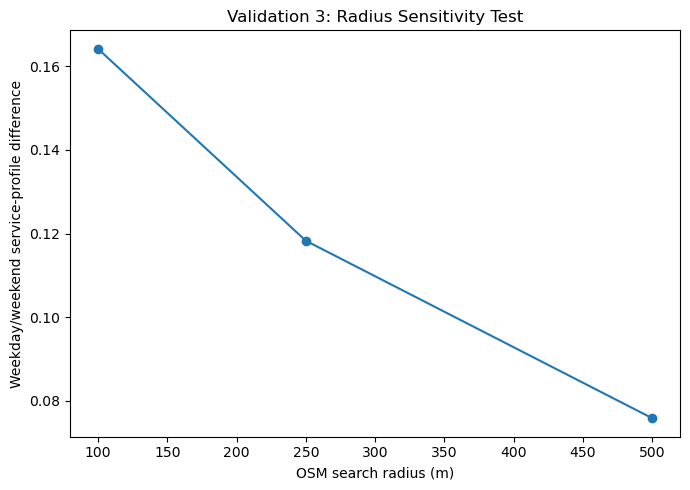

Saved: outputs\validation3_radius_sensitivity_profile_difference.png


In [10]:
plt.figure(figsize=(7, 5))
plt.plot(
    sensitivity_table["radius_m"],
    sensitivity_table["profile_difference_l1"],
    marker="o"
)

plt.xlabel("OSM search radius (m)")
plt.ylabel("Weekday/weekend service-profile difference")
plt.title("Validation 3: Radius Sensitivity Test")
plt.tight_layout()

output_fig = os.path.join(
    OUTPUT_DIR,
    "validation3_radius_sensitivity_profile_difference.png"
)

plt.savefig(output_fig, dpi=300)
plt.show()

print("Saved:", output_fig)

radius_m,100,250,500
service_category,,,
education,0.000904,-0.000473,-0.000235
food_drink,-0.033989,-0.028467,-0.018241
health,-0.000635,-0.000577,-0.000262
office,-0.003167,-0.004350,-0.004423
other_amenity,-0.000358,0.006984,-0.005890
recreation,0.066086,0.038218,0.019428
retail,-0.013226,-0.006417,-0.004108
tourism,0.015097,0.013931,0.018483
transit,-0.030711,-0.018850,-0.004753


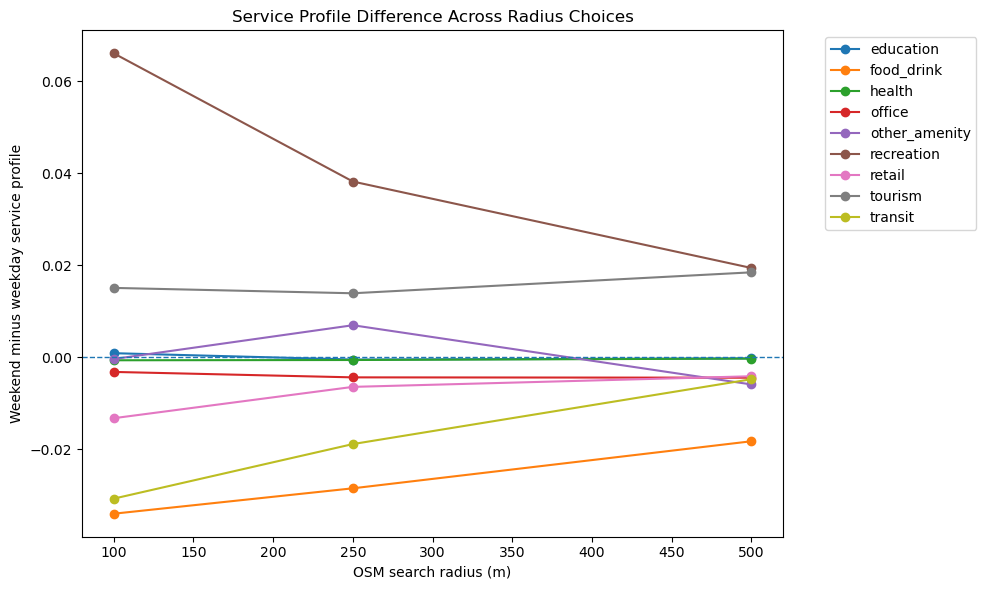

Saved: outputs\validation3_service_difference_by_radius.png


In [11]:
pivot_detail = profile_detail_table.pivot_table(
    index="service_category",
    columns="radius_m",
    values="weekend_minus_weekday",
    fill_value=0
)

display(pivot_detail)

pivot_detail.to_csv(
    os.path.join(OUTPUT_DIR, "validation3_radius_sensitivity_service_pivot.csv")
)

plt.figure(figsize=(10, 6))

for service in pivot_detail.index:
    plt.plot(
        pivot_detail.columns,
        pivot_detail.loc[service],
        marker="o",
        label=service
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("OSM search radius (m)")
plt.ylabel("Weekend minus weekday service profile")
plt.title("Service Profile Difference Across Radius Choices")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

output_fig = os.path.join(
    OUTPUT_DIR,
    "validation3_service_difference_by_radius.png"
)

plt.savefig(output_fig, dpi=300)
plt.show()

print("Saved:", output_fig)